# Digital Modulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from rfproto import filter, impairments, measurements, modulation, plot, sig_gen

## Chirp

A [**chirp**](https://en.wikipedia.org/wiki/Chirp) is a signal where the frequency increases (_up-chirp_) or decreases (_down-chirp_) with time, (also known as a frequency sweep).
* [ ] [Coherent Processing of Up/Down Linear Frequency Modulated Chirps - Sandia National Lab](https://www.osti.gov/servlets/purl/1716574)

### Linear Frequency Modulated (LFM) Chirp

In LFM chirp, the instantaneous frequency, $f(t)$ (in Hz), varies linearly with time:
$$f(t) = ct + f_{0}$$

where $f_{0}$ is the starting frequency (Hz), and $c$ is the constant chirp rate given an end frequency $f_{1}$ (Hz) and the sweep time between frequencies $T$:
$$c = \frac{f_{1} - f_{0}}{T}$$

Since [frequency is the derivative of phase](https://en.wikipedia.org/wiki/Instantaneous_phase_and_frequency) (e.g. $\omega(t) = \frac{d\phi(t)}{dt}$), and frequency is linearly changing (increasing or decreasing), it is expected that phase changes _quadratic_ over time, as shown by:
$$\phi(t) = \phi_{0} + 2\pi \int^{t}_{0}f(\tau)d\tau \rightarrow \phi_{0} + 2\pi \int^{t}_{0}(c\tau + f_{0})d\tau $$
$$\therefore \phi(t) = \phi_{0} + 2\pi \left( \frac{c}{2}t^{2} + f_{0}t \right)$$

The corresponding time-domain output is simply the $\sin()$ of this phase function, or $e^{j\phi(t)}$ for complex output.

In [ ]:
f_start = 10e3
f_end = 40e3
fs = 100e3
num_samples = 10000

lfm_chirp_sig = sig_gen.cmplx_dt_lfm_chirp(1, f_start, f_end, fs, num_samples)
freq, y_PSD = measurements.PSD(lfm_chirp_sig, fs, norm=True)
plot.freq_sig(freq, y_PSD, "LFM Chirp Spectrum", scale_noise=True)
plt.show()

## Phase Shift-Keying (PSK)

[Phase-shift keying- Wikipedia](https://en.wikipedia.org/wiki/Phase-shift_keying)

### Binary Phase-Shift Keying (BPSK)

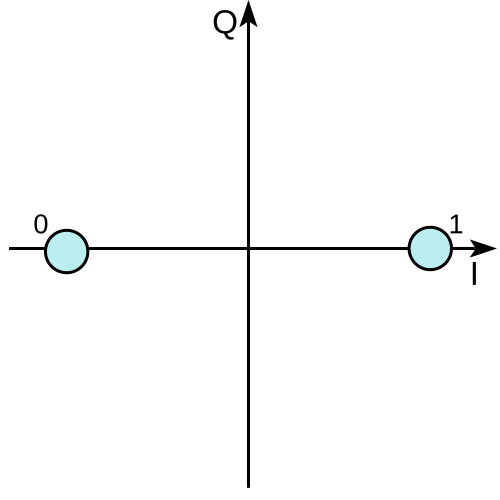

### Quadrature Phase-Shift Keying (QPSK)

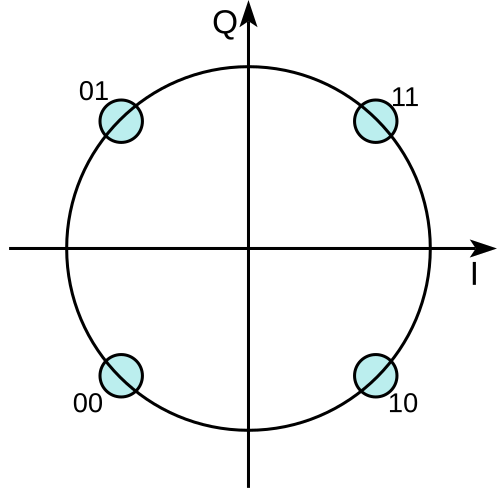

## Direct Sequence Spread Spectrum (DSSS)

[DSSS](https://en.wikipedia.org/wiki/Direct-sequence_spread_spectrum) spreads baseband signal energy over a wider spectral bandwidth using a spreading sequence. Receivers operate by [cross-correlating](https://john-gentile.com/kb/dsp/intro_to_dsp.html#continuous-time-correlation) the known, shared spreading sequence to despread the received DSSS signal.

Given an input bit rate or $R_{b}$ bits/sec, an $N$ bit spreading sequence/code produces an output chip rate $R_{c} = N \times R_{b}$. The length of the spreading code is also known as the _Spreading Factor (SF)_, also equal to $\frac{R_{c}}{R_{b}}$.

The signal spreading process also spreads any interference and noise across the entire bandwidth, effectively reducing its power relative to the main signal. We can calculate the processing gain of a spread spectrum signal with:
$$ P_{dB} = 10\log_{10}(N) $$

Spreading provides benefits such as:
* [Code-Division Multiple Access (CDMA)](https://en.wikipedia.org/wiki/Code-division_multiple_access): where multiple users can reuse the same frequency band at the same time by using different spreading codes.
* Jamming/interference resistance due to processing gain as well as spread bandwidth.
  - For example a jammer would have to jam the entire spread bandwidth or narrowband interference could be removed via notch filtering without much loss of information (especially if coding/forward-error-correction is used on the data).
  - Similar resistance to nominal channel fading exists since only a small portion of the signal will undergo fading at a given time.
* Below-noise-floor signal reception for either low signal detection or low power usage like in [GPS](https://john-gentile.com/kb/dsp/PNT.html#gps)
* Timing or ranging information between transmitter and receiver due to coherent correlation processes.
* Resistant to multipath interference due to delayed versions of the spread signal having poor correlation with the main spread signal(as long as the multipath channel induces at least one chip of delay).
* Depending on acquisition design of a receiver, can handle extremely high [Doppler](https://en.wikipedia.org/wiki/Doppler_effect) shifts.

In [ ]:
barker_bits = np.array([1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0]) # 11-bit barker code
# NRZL encoding [1/0 -> +1/-1]
barker_nrz= 2 * barker_bits - 1

plot.bits(barker_nrz, "11-bit Barker Code")
plt.show()

In [ ]:
data_bits = [1, 0, 1]
plot.bits(data_bits)
plt.show()

# Interpolate/upsample each bit by length of spread sequence
data_spread = np.repeat(data_bits, len(barker_bits))

plot.bits(data_spread)
plt.show()
print(len(data_spread))

In [ ]:
for i in range(len(data_spread)):
    data_spread[i] ^= barker_bits[i % len(barker_bits)]

data_nrz = 2 * np.array(data_spread) - 1
plot.bits(data_nrz)
plt.show()

In [ ]:
# sliding correlation of the transmitted sequence with the reference code:
# NOTE: inverted Barker NRZL spread code since direct XOR operation above
result = np.correlate(data_nrz, -barker_nrz, mode='full')

In [ ]:
plt.plot(result)
plt.show()
print(max(result))
print(np.argmax(result))

In [ ]:
tx = np.zeros(100)
tx[21:21+len(data_nrz)] = data_nrz 
tx += np.random.normal(-0.5, 0.5, 100)
plt.plot(tx)
plt.show()

In [ ]:
result = np.correlate(tx, -barker_nrz, mode='full')
plt.plot(result)
plt.show()
print(f"Max correlation of {max(result)} at {list(result).index(max(result))}")

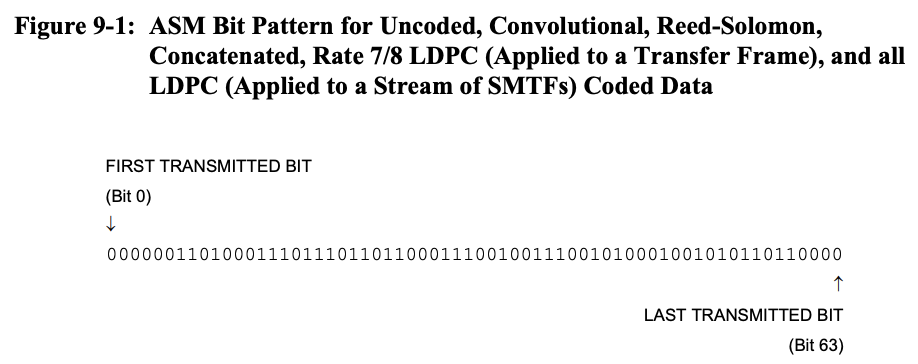

In [ ]:
# CCSDS 64b ASM (https://ccsds.org/Pubs/131x0b5.pdf)
ccsds_asm_64b = 0x034776C7272895B0
# Convert from 64b number to bit string
asm_bits = [(ccsds_asm_64b >> i) & 1 for i in range(63, -1, -1)]
plot.bits(asm_bits)
plt.show()

In [ ]:
asm_qpsk_symbols = []
for i in range(len(asm_bits) // 2):
    sym = (asm_bits[i*2] << 1) | asm_bits[(i*2)+1]
    asm_qpsk_symbols.append(sym)

print(asm_qpsk_symbols)

In [ ]:
# Generate 100 random QPSK payload symbols
rand_symbols = np.random.randint(0, 4, 100)
packet_symbols = []
packet_symbols.extend(asm_qpsk_symbols)
packet_symbols.extend(rand_symbols)
print(packet_symbols)

In [ ]:
sym_rate = 1e6             # Baseband symbol rate
L        = 4               # Upsample ratio (Samples per Symbol)
fs       = L * sym_rate    # Output sample rate (Hz)

rolloff          = 0.5     # Alpha of RRC
num_filt_symbols = 6       # Symbol length of RRC matched filter

qpsk_tx_filtered = sig_gen.gen_mod_signal(
    "QPSK",
    packet_symbols,
    fs,
    sym_rate,
    "RRC",
    rolloff,
    num_filt_symbols,
)

In [ ]:
test_sig = impairments.awgn(-30, 12 * len(qpsk_tx_filtered))
phase_offset = int(2.1 * len(qpsk_tx_filtered))
test_sig[phase_offset:phase_offset+len(qpsk_tx_filtered)] += qpsk_tx_filtered
print(f"Phase offset: {phase_offset}")

In [ ]:
plot.spec_an(test_sig, fs=fs, fft_shift=True, show_SFDR=False, y_unit="dB")
plt.show()

In [ ]:
plt.specgram(test_sig, pad_to=1024, Fs=fs)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

In [ ]:
mod = modulation.MPSKModulation(4)
asm_iq = mod.modulate(asm_qpsk_symbols)
print(asm_iq)

In [ ]:
asm_iq_upsampled = np.repeat(asm_iq, L)
print(asm_iq_upsampled)

In [ ]:
asm_fft = np.conj(np.fft.fft(asm_iq_upsampled))

corrs = []
for i in range(len(test_sig) // len(asm_fft)):
    start_idx = i * len(asm_fft)
    end_idx = (i + 1) * len(asm_fft)
    xcorr = np.fft.ifft(np.fft.fft(test_sig[start_idx:end_idx]) * asm_fft)
    corrs.extend(np.abs(xcorr) ** 2)

plt.plot(corrs)
plt.show()
print(np.argmax(corrs))

## Orthogonal Frequency-Division Multiplexing (OFDM)

[Orthogonal Frequency-Division Multiplexing](https://en.wikipedia.org/wiki/Orthogonal_frequency-division_multiplexing)

In [ ]:
from IPython.display import YouTubeVideo

In [ ]:
YouTubeVideo('1rpoUqx0360')

In [ ]:
YouTubeVideo('UCRildDdrX4')

## References

* [The History of Orthogonal Frequency-Division Multiplexing (OFDM) - IEEE](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=5307460)